In [1]:
import torch
from dataset.climatenet import ClimateDataset 
from torch.utils.data import DataLoader
from functools import partial
import random
import numpy as np
import os

def setup_device_and_distributed(worker_id):
    gpu_num = 1
    world_size = os.environ['WORLD_SIZE'] if 'WORLD_SIZE' in os.environ.keys() else gpu_num
    base_rank = os.environ['RANK'] if 'RANK' in os.environ.keys() else 0
    local_rank = (base_rank * gpu_num) + worker_id

    device = torch.device(f"cuda:{worker_id}")
    torch.cuda.set_device(device)
    return device, local_rank

device, local_rank = setup_device_and_distributed(0)

data_dir = "../data/"
val_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=False, transforms=None
    )
val_collate_fn = val_dataset.collate_fn
debug_size = 10
indices = list(range(min(debug_size, len(val_dataset))))
train_dataset = torch.utils.data.Subset(val_dataset, indices)

def worker_init_fn(worker_id: int, base_seed: int, same_worker_seed: bool = True):
    """
    Set random seed for each worker in DataLoader to ensure the reproducibility.

    """
    seed = base_seed if same_worker_seed else base_seed + worker_id

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    

val_dataloader = DataLoader(
        dataset=val_dataset, batch_size=2, shuffle=False, num_workers=0,
        drop_last=False, collate_fn=val_collate_fn, worker_init_fn=partial(worker_init_fn, base_seed=3407)
    )

In [ ]:
import os
import csv
import torch
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


def plot_mask_with_points_and_bbox(mask, ar_points=None, tc_points=None, ar_bbox=None, tc_bbox=None, 
                                   tc_pred_mask=None, ar_pred_mask=None, radius=8, save_path='exp', axis=False):
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    
    # Custom colormap: 0=black, 1=yellow, 2=blue
    cmap = ListedColormap(['black', 'yellow', 'blue'])
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(mask, cmap=cmap, vmin=0, vmax=2, alpha=0.7)

    legend_elements = [
        plt.Line2D([0], [0], marker='x', color='w', label='AR Point', markerfacecolor='red', markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], marker='x', color='w', label='TC Point', markerfacecolor='cyan', markersize=10, markeredgecolor='black'),
        plt.Line2D([0], [0], color='red', lw=2, label='AR BBox'),
        plt.Line2D([0], [0], color='cyan', lw=2, label='TC BBox'),
        plt.Line2D([0], [0], color='yellow', lw=0, marker='s', label='TC Groundtruth', markerfacecolor='yellow', markersize=10),
        plt.Line2D([0], [0], color='blue', lw=0, marker='s', label='AR Groundtruth', markerfacecolor='blue', markersize=10),
        plt.Line2D([0], [0], color='black', lw=0, marker='s', label='Background', markerfacecolor='black', markersize=10)
    ]

    csv_rows = []  # collect rows to save: kind,label,x,y,x2,y2

    def _points_to_array(obj):
        if obj is None:
            return np.empty((0, 2))
        # If list/tuple (batched), use first element like original code
        if isinstance(obj, (list, tuple)):
            obj = obj[0]
        if isinstance(obj, torch.Tensor):
            pts = obj
            if pts.ndim == 3:
                pts = pts.squeeze(1)
            pts = pts.cpu().numpy()
        else:
            pts = np.asarray(obj)
            if pts.ndim == 3:
                pts = pts.squeeze(1)
        if pts.size == 0:
            return np.empty((0, 2))
        pts = pts.reshape(-1, 2)
        return pts

    def _bboxes_to_list(obj):
        bboxes = []
        if obj is None:
            return bboxes
        # If it's a list/tuple of per-sample tensors, iterate through elements
        if isinstance(obj, (list, tuple)):
            for item in obj:
                if item is None:
                    continue
                if isinstance(item, torch.Tensor):
                    arr = item.squeeze(1).cpu().numpy() if item.ndim == 3 else item.cpu().numpy()
                else:
                    arr = np.asarray(item)
                    if arr.ndim == 3:
                        arr = arr.squeeze(1)
                arr = np.atleast_2d(arr.reshape(-1, 4))
                bboxes.extend(arr.tolist())
            return bboxes
        # Single tensor/array
        if isinstance(obj, torch.Tensor):
            arr = obj.squeeze(1).cpu().numpy() if obj.ndim == 3 else obj.cpu().numpy()
        else:
            arr = np.asarray(obj)
            if arr.ndim == 3:
                arr = arr.squeeze(1)
        arr = np.atleast_2d(arr.reshape(-1, 4))
        bboxes.extend(arr.tolist())
        return bboxes

    # Plot AR points
    if ar_points is not None and (not isinstance(ar_points, (list, tuple)) or ar_points[0] is not None):
        points = _points_to_array(ar_points)
        for x, y in points:
            ax.scatter(x, y, marker='x', color='red', s=100, linewidth=3)
            csv_rows.append(['point', 'AR', float(x), float(y), '', ''])

    # Plot TC points
    if tc_points is not None and (not isinstance(tc_points, (list, tuple)) or tc_points[0] is not None):
        points = _points_to_array(tc_points)
        for x, y in points:
            ax.scatter(x, y, marker='x', color='cyan', s=100, linewidth=3)
            csv_rows.append(['point', 'TC', float(x), float(y), '', ''])

    # Plot AR bounding boxes
    if ar_bbox is not None:
        bboxes = _bboxes_to_list(ar_bbox)
        for bbox in bboxes:
            x1, y1, x2, y2 = map(float, bbox)
            width = x2 - x1
            height = y2 - y1
            rect = plt.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            csv_rows.append(['bbox', 'AR', x1, y1, x2, y2])

    # Plot TC bounding boxes
    if tc_bbox is not None:
        bboxes = _bboxes_to_list(tc_bbox)
        for bbox in bboxes:
            x1, y1, x2, y2 = map(float, bbox)
            width = x2 - x1
            height = y2 - y1
            rect = plt.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='cyan', facecolor='none')
            ax.add_patch(rect)
            csv_rows.append(['bbox', 'TC', x1, y1, x2, y2])

    # Plot AR prediction mask as contour lines
    if ar_pred_mask is not None:
        if isinstance(ar_pred_mask, torch.Tensor):
            ar_pred_np = ar_pred_mask.cpu().numpy()
        else:
            ar_pred_np = ar_pred_mask
        
        if ar_pred_np.ndim > 2:
            ar_pred_np = ar_pred_np.squeeze()
        
        # Plot contour lines for AR predictions
        ax.contour(ar_pred_np, levels=[0.5], colors=['orange'], linewidths=2, linestyles='--')
        legend_elements.append(plt.Line2D([0], [0], color='orange', lw=2, linestyle='--', label='AR Prediction'))

    # Plot TC prediction mask as contour lines
    if tc_pred_mask is not None:
        if isinstance(tc_pred_mask, torch.Tensor):
            tc_pred_np = tc_pred_mask.cpu().numpy()
        else:
            tc_pred_np = tc_pred_mask
        
        if tc_pred_np.ndim > 2:
            tc_pred_np = tc_pred_np.squeeze()
        
        # Plot contour lines for TC predictions
        ax.contour(tc_pred_np, levels=[0.5], colors=['magenta'], linewidths=2, linestyles='-.')
        legend_elements.append(plt.Line2D([0], [0], color='magenta', lw=2, linestyle='-.', label='TC Prediction'))

    ax.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(1, -0.25), frameon=False, fontsize=14, ncol=4, columnspacing=0.5)
    ax.set_title("Mask with AR/TC Points, BBoxes and Predictions", fontsize=16)

    # Show or hide axis/ruler
    if axis:
        h, w = mask.shape
        max_ticks = 10
        x_ticks = np.unique(np.round(np.linspace(0, w - 1, min(max_ticks, w))).astype(int))
        y_ticks = np.unique(np.round(np.linspace(0, h - 1, min(max_ticks, h))).astype(int))
        ax.set_xticks(x_ticks)
        ax.set_yticks(y_ticks)
        ax.set_xticklabels([str(int(t)) for t in x_ticks], fontsize=10)
        ax.set_yticklabels([str(int(t)) for t in y_ticks], fontsize=10)
        ax.tick_params(axis='both', which='major', length=6)
        ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.6)
    else:
        ax.axis('off')
    
    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)

    # Save prompts (points and bboxes) to a CSV with the same base name as save_path
    csv_path = os.path.splitext(save_path)[0] + '.csv'
    if csv_rows:
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['kind', 'label', 'x', 'y', 'x2', 'y2'])
            writer.writerows(csv_rows)

    plt.close(fig)
    
    return fig

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
torch.Size([768, 1152])
tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
torch.Size([768, 1152])
tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
torch.Size([768, 1152])
tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
torch.Size([768, 1152])
tensor([[0, 0, 0,  ..., 0, 0, 0]

KeyboardInterrupt: 

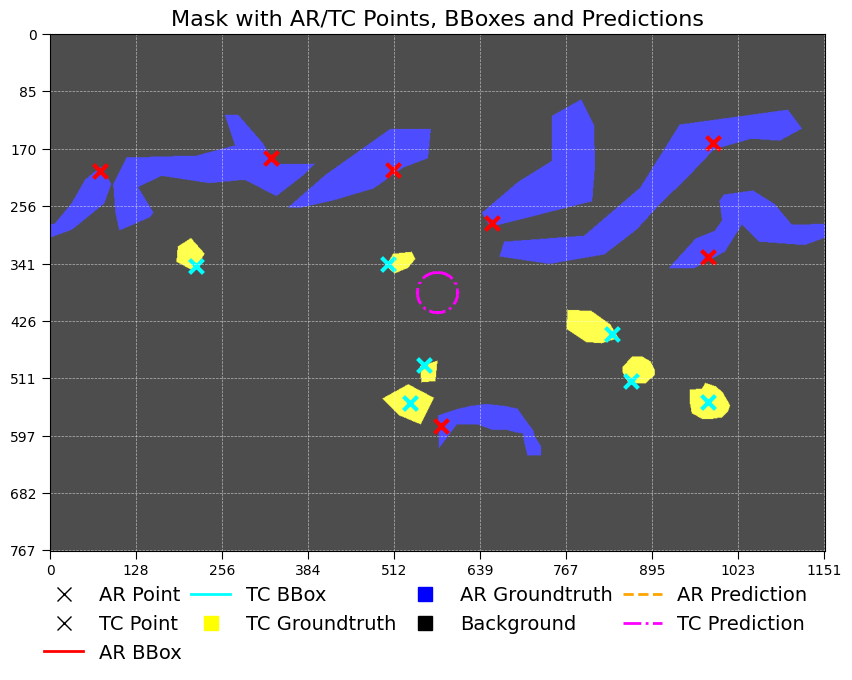

In [5]:
import matplotlib.pyplot as plt
from train_util import batch_to_cuda
for val_step, batch in enumerate(val_dataloader):
    batch = batch_to_cuda(batch, device)
    ar_points = batch['ar_point_prompts'] #list of (batch, num_points, 2) tensor or None
    tc_points = batch['tc_point_prompts'] #list of (batch, num_points, 2) tensor or None
    ar_bbox = batch['ar_bbox_prompts']  # list of (batch, num_boxes, 1, 4) tensor or None
    tc_bbox = batch['tc_bbox_prompts']  # list of (batch, num_boxes, 1, 4) tensor or None
    mask = batch['gt_mask']
    # if ar_points is not None:
    #     print(len(ar_bbox))
    #     print(ar_bbox)
    #     print(ar_bbox[0].shape)
    mask = mask[0]  # (H, W)
    print(mask)
    ar_points_0 = batch['ar_point_prompts'][0]
    tc_points_0 = batch['tc_point_prompts'][0]
    ar_bbox_0 = batch['ar_bbox_prompts'][0]
    tc_bbox_0 = batch['tc_bbox_prompts'][0]

    print(mask.shape)

    tc_pred_mask = torch.zeros_like(mask)
    center_y, center_x = tc_pred_mask.shape[0] // 2, tc_pred_mask.shape[1] // 2
    radius = 30
    Y, X = torch.meshgrid(torch.arange(tc_pred_mask.shape[0]), torch.arange(tc_pred_mask.shape[1]), indexing='ij')
    dist = (X - center_x) ** 2 + (Y - center_y) ** 2
    tc_pred_mask[dist <= radius ** 2] = 1
    ar_pred_mask = torch.zeros_like(mask)  # Dummy prediction mask for AR



    fig = plot_mask_with_points_and_bbox(mask, ar_points_0, tc_points_0, ar_bbox_0, tc_bbox_0, tc_pred_mask, ar_pred_mask, radius=8, save_path=f'exp/debug/val_step_{val_step}.png', axis =True)
    
    


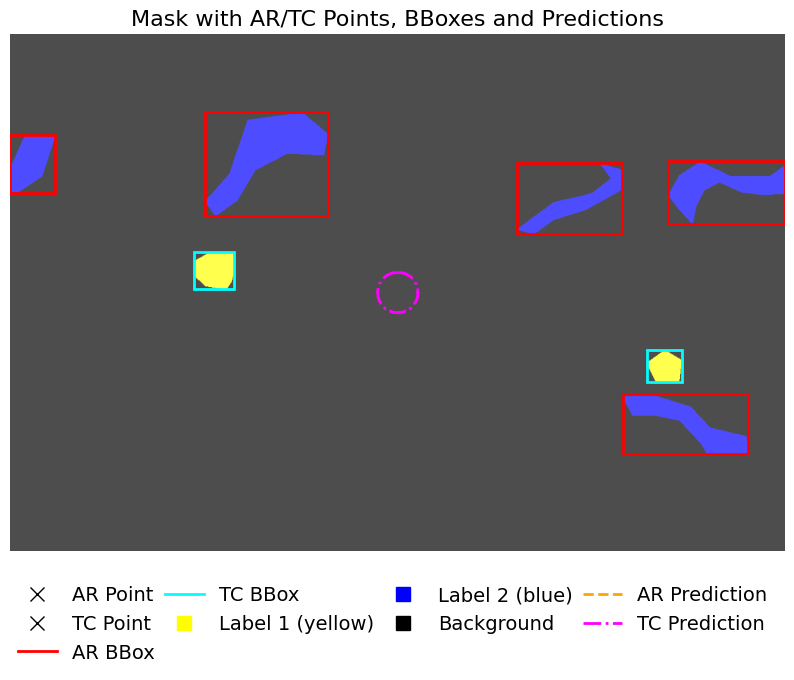

In [149]:
fig

In [ ]:
import matplotlib.pyplot as plt
for val_step, batch in enumerate(train_dataloader):
    



    plot_mask_with_points_and_bbox(mask, ar_points_0, tc_points_0, ar_bbox_0, tc_bbox_0, radius=8)
    
    break


In [2]:
import matplotlib.pyplot as plt
def plot_mask_with_prompts(mask, ar_points=None, tc_points=None, ar_bbox=None, tc_bbox=None, 
                        wandb_log=False, wandb_key="mask_with_prompts", epoch=None):
    """
    Plot ground truth mask with various prompts overlaid for visualization.
    
    Args:
        mask: Ground truth mask tensor (H, W) where 0=background, 1=TC, 2=AR
        ar_points: AR point prompts tensor of shape (N, 3) where each point is [x, y, label]
        tc_points: TC point prompts tensor of shape (N, 3) where each point is [x, y, label]
        ar_bbox: AR bounding box prompts tensor of shape (N, 4) where each box is [x1, y1, x2, y2]
        tc_bbox: TC bounding box prompts tensor of shape (N, 4) where each box is [x1, y1, x2, y2]
        wandb_log: Whether to log to wandb
        wandb_key: Key for wandb logging
        epoch: Current epoch number
    
    Returns:
        matplotlib figure object
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np
    
    # Convert mask to numpy if it's a tensor
    if hasattr(mask, 'cpu'):
        mask_np = mask.cpu().numpy()
    else:
        mask_np = mask
    
    # Squeeze any extra dimensions
    if len(mask_np.shape) > 2:
        mask_np = mask_np.squeeze()
    
    # Create figure and axis
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create colored mask: background=black, TC=blue, AR=red
    colored_mask = np.zeros((*mask_np.shape, 3))
    colored_mask[mask_np == 1] = [0, 0, 1]  # TC = blue
    colored_mask[mask_np == 2] = [1, 0, 0]  # AR = red
    
    ax.imshow(colored_mask, alpha=0.7)
    ax.set_title(f'Ground Truth Mask with Prompts (Epoch {epoch})')
    
    # Plot AR point prompts
    if ar_points is not None and len(ar_points) > 0:
        if hasattr(ar_points, 'cpu'):
            ar_points_np = ar_points.cpu().numpy()
        else:
            ar_points_np = ar_points
            
        for point in ar_points_np:
            x, y, label = point[0], point[1], point[2]
            color = 'yellow' if label == 1 else 'orange'  # positive=yellow, negative=orange
            marker = 'o' if label == 1 else 'x'
            ax.scatter(x, y, c=color, s=100, marker=marker, edgecolors='black', linewidth=2, label=f'AR Point ({label})')
    
    # Plot TC point prompts
    if tc_points is not None and len(tc_points) > 0:
        if hasattr(tc_points, 'cpu'):
            tc_points_np = tc_points.cpu().numpy()
        else:
            tc_points_np = tc_points
            
        for point in tc_points_np:
            x, y, label = point[0], point[1], point[2]
            color = 'cyan' if label == 1 else 'purple'  # positive=cyan, negative=purple
            marker = 'o' if label == 1 else 'x'
            ax.scatter(x, y, c=color, s=100, marker=marker, edgecolors='black', linewidth=2, label=f'TC Point ({label})')
    
    # Plot AR bounding boxes
    if ar_bbox is not None and len(ar_bbox) > 0:
        if hasattr(ar_bbox, 'cpu'):
            ar_bbox_np = ar_bbox.cpu().numpy()
        else:
            ar_bbox_np = ar_bbox
            
        for bbox in ar_bbox_np:
            x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]
            width = x2 - x1
            height = y2 - y1
            rect = patches.Rectangle((x1, y1), width, height, linewidth=3, 
                                edgecolor='yellow', facecolor='none', 
                                linestyle='--', label='AR BBox')
            ax.add_patch(rect)
    
    # Plot TC bounding boxes
    if tc_bbox is not None and len(tc_bbox) > 0:
        if hasattr(tc_bbox, 'cpu'):
            tc_bbox_np = tc_bbox.cpu().numpy()
        else:
            tc_bbox_np = tc_bbox
            
        for bbox in tc_bbox_np:
            x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]
            width = x2 - x1
            height = y2 - y1
            rect = patches.Rectangle((x1, y1), width, height, linewidth=3, 
                                edgecolor='cyan', facecolor='none', 
                                linestyle='--', label='TC BBox')
            ax.add_patch(rect)
    
    # Add legend (remove duplicates)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.0, 1.0))
    
    # Add color legend for mask
    legend_elements = [
        patches.Patch(color='blue', label='TC (Tropical Cyclone)'),
        patches.Patch(color='red', label='AR (Atmospheric River)'),
        patches.Patch(color='black', label='Background')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.0, 1.0))
    
    ax.set_xlim(0, mask_np.shape[1])
    ax.set_ylim(mask_np.shape[0], 0)  # Flip y-axis for image coordinates
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    
    plt.tight_layout()
    
    # Log to wandb if requested
    if wandb_log:
        import wandb
        wandb.log({
            wandb_key: wandb.Image(fig, caption=f"Ground truth mask with prompts - Epoch {epoch}")
        }, step=epoch)
    
    return fig

In [123]:
def plot_with_projection(image, ar_pred, tc_pred, ar_gt, tc_gt, save_path, use_projection=True, epoch=None, title = None):
    ar_gt_color = 'red'
    tc_gt_color = 'green'
    ar_pred_color = 'orange'
    tc_pred_color = 'blue'
    alpha_gt = 0.5
    alpha_pred = 0.3
    
    # PREPROCESSING
    ar_pred = ar_pred.squeeze() if ar_pred is not None else None
    tc_pred = tc_pred.squeeze() if tc_pred is not None else None
    ar_gt = ar_gt.squeeze() if ar_gt is not None else None
    tc_gt = tc_gt.squeeze() if tc_gt is not None else None
    # height, width = tc_gt.shape[1], image.shape[2]
    # Convert tensors to numpy arrays
    image_np = image.cpu().numpy() if torch.is_tensor(image) else image
    # print("Image shape:", image_np.shape)
    if image_np.shape[0] == 3:
        image_np = np.squeeze(image_np)
        image_np = image_np.transpose(1, 2, 0)
    # Normalize image data to [0, 1] range for imshow
    min_val = image_np.min()
    max_val = image_np.max()
    image_np = (image_np - min_val) / (max_val - min_val)
    # image_np = np.clip(image_np, 0, 1)
    # Resize the image to 1024x1024 using interpolation
    image_np = cv2.resize(image_np, (1152, 768), interpolation=cv2.INTER_LINEAR)
    longitudes = np.linspace(-180, 180, image_np.shape[1])
    latitudes = np.linspace(-90, 90, image_np.shape[0])
    
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()} if use_projection else {})
    ax.gridlines(x_inline=True)
    # Plot the RGB image
    ax.imshow(image_np, origin='upper', extent=[-180, 180, -90, 90] if use_projection else None, alpha=0.5)
    ax.set_global()
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    
    ar_gt_line = plt.Line2D([0], [0], color=ar_gt_color, linewidth=1, label='AR Ground Truth')
    tc_gt_line = plt.Line2D([0], [0], color=tc_gt_color, linewidth=1, label='TC Ground Truth')
    # Plot the mask contours
    ax.contourf(longitudes, latitudes, ar_gt, colors=ar_gt_color, levels=[0.5, 1.0], alpha = alpha_gt, transform=ccrs.PlateCarree() if use_projection else None)
    ax.contourf(longitudes, latitudes, tc_gt, colors=tc_gt_color, levels=[0.5, 1.0], alpha = alpha_gt, transform=ccrs.PlateCarree() if use_projection else None)
    
    # PREPROCESSING
    ar_gt = ar_gt.cpu().numpy().squeeze() if torch.is_tensor(ar_gt) else ar_gt.squeeze() 
    tc_gt = tc_gt.cpu().numpy().squeeze() if torch.is_tensor(tc_gt) else tc_gt.squeeze()
    if ar_pred is not None:
        ar_pred = ar_pred.detach().cpu().numpy().squeeze() if torch.is_tensor(ar_pred) else ar_pred.squeeze()
        if ar_pred.ndim == 3:
            for pred in ar_pred:
                ax.contourf(longitudes, latitudes, pred, colors=ar_pred_color, levels=[0.5, 1.0], alpha = alpha_pred, transform=ccrs.PlateCarree() if use_projection else None)
        ac_pred_line = plt.Line2D([0], [0], color=ar_pred_color, linewidth=1, label='AC Prediction')

        
    if tc_pred is not None:
        tc_pred = tc_pred.detach().cpu().numpy().squeeze() if torch.is_tensor(tc_pred) else tc_pred.squeeze()
        if tc_pred.ndim == 3:
            for pred in tc_pred:
                ax.contourf(longitudes, latitudes, pred, colors=tc_pred_color, levels=[0.5, 1.0], alpha = alpha_pred, transform=ccrs.PlateCarree() if use_projection else None)
        tc_red_line = plt.Line2D([0], [0], color=tc_pred_color, linewidth=1, label='TC Prediction')


    handles = [ar_gt_line, ac_pred_line, tc_gt_line, tc_red_line]
    
    plt.legend(handles=handles, loc='upper right')

    # Add title and labels
    if title is None:
        title = f'World projection with RGB  - Epoch {epoch}'
        
    plt.title(title)
    # Save the plot to a numpy array
    fig.canvas.draw()
    plot_array = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    plot_array = plot_array.reshape(fig.canvas.get_width_height()[::-1] + (3,))

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)
    
    return plot_array, title

In [13]:
import numpy as np

ar_masks_per_image = []
tc_masks_per_image = []
ar_pixels_per_image = []
tc_pixels_per_image = []
ar_bg_obj_ratios = []
tc_bg_obj_ratios = []

for i in range(len(train_dataset)):
    # Get AR and TC object masks
    ar_masks = train_dataset[i]['ar_object_masks']
    tc_masks = train_dataset[i]['tc_object_masks']

    # Handle None cases
    if ar_masks is None:
        num_ar_masks = 0
        ar_pixels = []
        ar_bg_obj_ratio = []
    else:
        num_ar_masks = ar_masks.shape[0]
        ar_pixels = ar_masks.reshape(num_ar_masks, -1).sum(axis=1) if num_ar_masks > 0 else []
        # Calculate background to object ratio for each mask
        if num_ar_masks > 0:
            total_pixels = ar_masks.shape[-2] * ar_masks.shape[-1]
            ar_bg_obj_ratio = [(total_pixels - p.item()) / p.item() if p.item() > 0 else np.nan for p in ar_pixels]
        else:
            ar_bg_obj_ratio = []

    if tc_masks is None:
        num_tc_masks = 0
        tc_pixels = []
        tc_bg_obj_ratio = []
    else:
        num_tc_masks = tc_masks.shape[0]
        tc_pixels = tc_masks.reshape(num_tc_masks, -1).sum(axis=1) if num_tc_masks > 0 else []
        if num_tc_masks > 0:
            total_pixels = tc_masks.shape[-2] * tc_masks.shape[-1]
            tc_bg_obj_ratio = [(total_pixels - p.item()) / p.item() if p.item() > 0 else np.nan for p in tc_pixels]
        else:
            tc_bg_obj_ratio = []

    ar_masks_per_image.append(num_ar_masks)
    tc_masks_per_image.append(num_tc_masks)
    ar_pixels_per_image.extend(ar_pixels.tolist() if hasattr(ar_pixels, 'tolist') else ar_pixels)
    tc_pixels_per_image.extend(tc_pixels.tolist() if hasattr(tc_pixels, 'tolist') else tc_pixels)
    ar_bg_obj_ratios.extend(ar_bg_obj_ratio)
    tc_bg_obj_ratios.extend(tc_bg_obj_ratio)

# Remove NaNs for ratio statistics
ar_bg_obj_ratios = [r for r in ar_bg_obj_ratios if not np.isnan(r)]
tc_bg_obj_ratios = [r for r in tc_bg_obj_ratios if not np.isnan(r)]

# Calculate statistics
print("AR masks per image: mean =", np.mean(ar_masks_per_image), ", median =", np.median(ar_masks_per_image))
print("TC masks per image: mean =", np.mean(tc_masks_per_image), ", median =", np.median(tc_masks_per_image))
print("AR mask pixels per image: mean =", np.mean(ar_pixels_per_image), ", median =", np.median(ar_pixels_per_image))
print("TC mask pixels per image: mean =", np.mean(tc_pixels_per_image), ", median =", np.median(tc_pixels_per_image))
print("AR background/object ratio: mean =", np.mean(ar_bg_obj_ratios), ", median =", np.median(ar_bg_obj_ratios))
print("TC background/object ratio: mean =", np.mean(tc_bg_obj_ratios), ", median =", np.median(tc_bg_obj_ratios))

AR masks per image: mean = 7.4296482412060305 , median = 7.0
TC masks per image: mean = 2.5603015075376883 , median = 2.0
AR mask pixels per image: mean = 6755.939803855259 , median = 6177.0
TC mask pixels per image: mean = 1595.9774288518156 , median = 1289.0
AR background/object ratio: mean = 351.3577548329763 , median = 142.23069451189897
TC background/object ratio: mean = 880.716766966197 , median = 685.3739332816136


In [11]:
tc_ratios = []
ar_ratios = []

for file in train_dataset.files:
    dataset = xr.load_dataset(file)
    mask = dataset['LABELS'].values

    # TC ratio (label == 1)
    tc_mask = mask == 1
    tc_ones_count = np.sum(tc_mask) + 1
    tc_zeros_count = np.sum(~tc_mask)
    tc_ratio = tc_zeros_count / tc_ones_count
    tc_ratios.append(tc_ratio)

    # AR ratio (label == 2)
    ar_mask = mask == 2
    ar_ones_count = np.sum(ar_mask) + 1
    ar_zeros_count = np.sum(~ar_mask)
    ar_ratio = ar_zeros_count / ar_ones_count
    ar_ratios.append(ar_ratio)

mean_tc_ratio = np.mean(tc_ratios)
median_tc_ratio = np.median(tc_ratios)
print("Mean TC ratio:", mean_tc_ratio)
print("Median TC ratio:", median_tc_ratio)

mean_ar_ratio = np.mean(ar_ratios)
median_ar_ratio = np.median(ar_ratios)
print("Mean AR ratio:", mean_ar_ratio)
print("Median AR ratio:", median_ar_ratio)


Mean TC ratio: 149220.24595852135
Median TC ratio: 257.2420611525207
Mean AR ratio: 2242.9477343671983
Median AR ratio: 16.982505712876822


In [9]:
tc_masks_per_image

[5,
 2,
 1,
 5,
 3,
 0,
 7,
 2,
 2,
 0,
 4,
 7,
 2,
 3,
 1,
 0,
 3,
 7,
 4,
 2,
 5,
 2,
 2,
 5,
 1,
 0,
 2,
 1,
 0,
 0,
 0,
 2,
 0,
 1,
 2,
 3,
 3,
 3,
 2,
 6,
 8,
 1,
 2,
 3,
 0,
 3,
 9,
 4,
 0,
 0,
 0,
 2,
 0,
 2,
 5,
 4,
 4,
 0,
 2,
 4,
 1,
 1,
 4,
 0,
 5,
 1,
 7,
 3,
 0,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 3,
 2,
 3,
 0,
 1,
 3,
 7,
 3,
 4,
 3,
 5,
 6,
 0,
 5,
 1,
 2,
 3,
 1,
 4,
 2,
 3,
 1,
 1,
 1,
 0,
 4,
 1,
 3,
 8,
 2,
 5,
 5,
 1,
 1,
 0,
 2,
 7,
 3,
 1,
 3,
 4,
 3,
 3,
 1,
 4,
 3,
 5,
 4,
 1,
 3,
 1,
 0,
 1,
 2,
 4,
 0,
 0,
 0,
 0,
 8,
 0,
 9,
 0,
 0,
 6,
 0,
 4,
 0,
 1,
 4,
 0,
 0,
 2,
 4,
 0,
 0,
 1,
 4,
 3,
 2,
 4,
 2,
 2,
 5,
 1,
 1,
 6,
 1,
 2,
 2,
 2,
 2,
 1,
 1,
 2,
 2,
 2,
 0,
 1,
 4,
 5,
 4,
 7,
 4,
 5,
 2,
 3,
 3,
 2,
 5,
 6,
 1,
 5,
 1,
 0,
 1,
 5,
 2,
 4,
 5,
 3,
 1,
 1,
 3,
 2,
 2,
 3,
 2,
 1,
 1,
 1,
 4,
 2,
 2,
 1,
 2,
 0,
 4,
 2,
 0,
 4,
 2,
 2,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 3,
 2,
 1,
 2,
 1,
 1,
 1,
 4,
 5,
 7,
 6,
 2,
 3,
 4,
 0,
 4,
 1,
 2,
 3,
 1,
 3,
 1,
 6,
 6,


In [12]:
ar_masks_per_image = []
tc_masks_per_image = []

In [2]:
import matplotlib.pyplot as plt 
def plot_mask(mask):
    """
    Plot a mask tensor.

    Parameters:
      mask: torch.Tensor, expected shape [batch, channel, height, width]
      i: int, index of the mask
      mask_type: str, used in the title and print statement
    """
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.colorbar()
    plt.show()

In [3]:
sample = train_dataset[0]
gt_mask = sample['gt_mask']
ar_bbox_prompts = sample['ar_bbox_prompts']
tc_bbox_prompts = sample['tc_bbox_prompts']
ar_point_prompts = sample['ar_point_prompts']
tc_point_prompts = sample['tc_point_prompts']
tc_mask_prompts = sample['tc_mask_prompts']

In [4]:
ar_point_prompts

(tensor([[[  57.,  163.]],
 
         [[ 116.,  271.]],
 
         [[ 479.,  318.]],
 
         [[ 345.,  277.]],
 
         [[ 695.,  294.]],
 
         [[1064.,  287.]],
 
         [[1065.,  495.]],
 
         [[ 567.,  530.]],
 
         [[ 671.,  559.]]]),
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.]]))

In [8]:
tc_point_prompts

(tensor([[[496., 362.]],
 
         [[698., 416.]],
 
         [[167., 444.]],
 
         [[856., 467.]],
 
         [[446., 494.]]]),
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.]]))

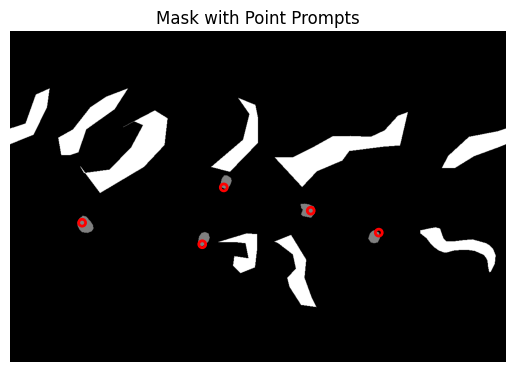

In [6]:
def plot_mask_with_points(mask, point_prompts, color='red', radius=8):
    """
    Plot a mask with point prompts as circles.

    Parameters:
      mask: numpy.ndarray or torch.Tensor, shape [H, W]
      point_prompts: tuple (points, labels), points shape [N, 1, 2] or [N, 2]
      color: str, color for the circles
      radius: int, radius of the circles
    """
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    points = point_prompts[0]
    if points.ndim == 3:
        points = points.squeeze(1)
    points = points.cpu().numpy()
    plt.figure()
    plt.imshow(mask, cmap='gray')
    for x, y in points:
        circle = plt.Circle((x,y), radius, color=color, fill=False, linewidth=2)
        plt.gca().add_patch(circle)
    plt.title("Mask with Point Prompts")
    plt.axis('off')
    plt.show()

plot_mask_with_points(gt_mask, tc_point_prompts)

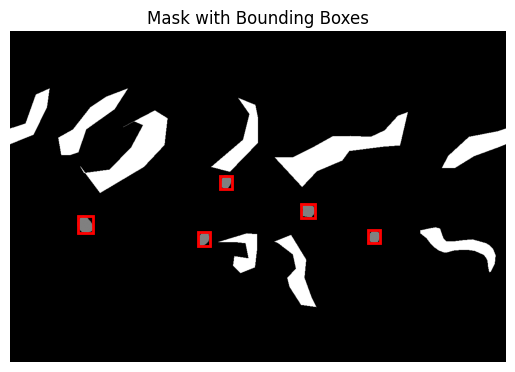

In [63]:
def plot_mask_with_bbox(mask, bbox_prompts, color='red'):
    """
    Plot a mask with bounding boxes.

    Parameters:
      mask: numpy.ndarray or torch.Tensor, shape [H, W]
      bbox_prompts: torch.Tensor, shape [N, 1, 4] or [N, 4]
      color: str, color for the bounding boxes
    """
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    plt.figure()
    plt.imshow(mask, cmap='gray')
    # Handle bbox_prompts shape
    bboxes = bbox_prompts.squeeze(1).cpu().numpy() if bbox_prompts.ndim == 3 else bbox_prompts.cpu().numpy()
    for bbox in bboxes:
        x1, y1, x2, y2 = bbox
        width = x2 - x1
        height = y2 - y1
        rect = plt.Rectangle((x1, y1), width, height, linewidth=2, edgecolor=color, facecolor='none')
        plt.gca().add_patch(rect)
    plt.title("Mask with Bounding Boxes")
    plt.axis('off')
    plt.show()

plot_mask_with_bbox(gt_mask, tc_bbox_prompts)

In [116]:
tc_objs = []
ar_objs = []
for i in range(len(train_dataset)):
    try:
        tc_objs.append(len(train_dataset[i]['tc_point_prompts'][1]))
    except:
        tc_objs.append(0)
        
    try:
        ar_objs.append(len(train_dataset[i]['ar_point_prompts'][1]))
    except:
        ar_objs.append(0)
        
        
